<a href="https://colab.research.google.com/github/lynnfdsouza/CUAS21/blob/main/acc_data_comparison01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Quadcopter Anomaly Detection System
Based on ADXL345 Accelerometer Data and IoT Integration
Generating dataset...
Dataset created: 1000 samples

Analyzing MEAN features

Training models...
Models trained successfully!

RF Results:
  Accuracy: 1.0000
  Precision (Normal/Anomalous): 1.0000 / 1.0000
  Recall (Normal/Anomalous): 1.0000 / 1.0000
  F1-Score (Normal/Anomalous): 1.0000 / 1.0000

SVM Results:
  Accuracy: 1.0000
  Precision (Normal/Anomalous): 1.0000 / 1.0000
  Recall (Normal/Anomalous): 1.0000 / 1.0000
  F1-Score (Normal/Anomalous): 1.0000 / 1.0000

KNN Results:
  Accuracy: 1.0000
  Precision (Normal/Anomalous): 1.0000 / 1.0000
  Recall (Normal/Anomalous): 1.0000 / 1.0000
  F1-Score (Normal/Anomalous): 1.0000 / 1.0000

NN Results:
  Accuracy: 1.0000
  Precision (Normal/Anomalous): 1.0000 / 1.0000
  Recall (Normal/Anomalous): 1.0000 / 1.0000
  F1-Score (Normal/Anomalous): 1.0000 / 1.0000

Analyzing RMS features

Training models...
Models trained successfully!

RF Results:
  Accu

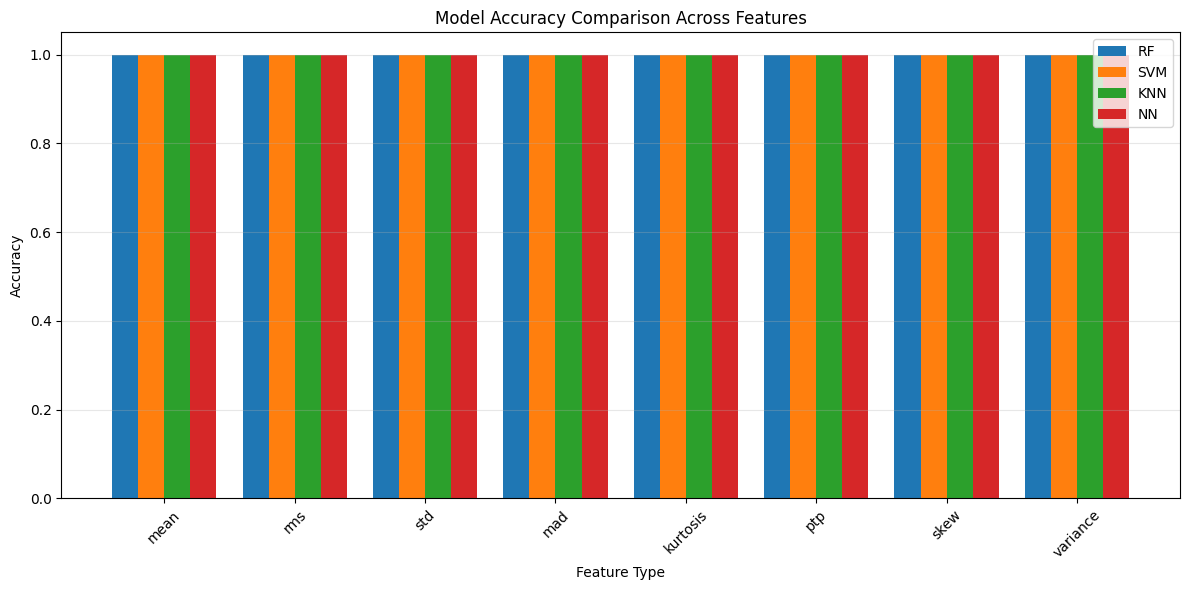


Best Configuration:
  Model: RF
  Feature: MEAN
  Accuracy: 1.0000

Analysis Complete!


In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from scipy import stats
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

class QuadcopterAnomalyDetection:
    """
    AI-driven anomaly detection system for quadcopters using accelerometer data
    """

    def __init__(self, sampling_rate=200, duration=120):
        self.sampling_rate = sampling_rate
        self.duration = duration
        self.scaler = StandardScaler()
        self.models = {}
        self.results = {}

    def generate_synthetic_data(self, n_samples=1000, anomaly=False):
        """
        Generate synthetic accelerometer data (3-axis)
        In real implementation, this would be replaced with actual ADXL345 data
        """
        np.random.seed(42)

        if not anomaly:
            # Normal operation - low vibration
            x = np.random.normal(-9.8, 0.5, n_samples)
            y = np.random.normal(0, 0.3, n_samples)
            z = np.random.normal(0, 0.3, n_samples)
        else:
            # Anomalous operation - high vibration due to damaged propeller
            x = np.random.normal(-9.8, 2.5, n_samples)
            y = np.random.normal(0, 2.0, n_samples)
            z = np.random.normal(0, 2.0, n_samples)
            # Add spikes to simulate damage
            spikes = np.random.randint(0, n_samples, size=int(n_samples * 0.1))
            x[spikes] += np.random.uniform(-5, 5, len(spikes))
            y[spikes] += np.random.uniform(-5, 5, len(spikes))
            z[spikes] += np.random.uniform(-5, 5, len(spikes))

        return np.column_stack([x, y, z])

    def extract_features(self, data):
        """
        Extract time-domain features from accelerometer data
        Features: Mean, RMS, Std, MAD, Kurtosis, PtP, Skewness, Variance
        """
        features = {}

        for i, axis in enumerate(['x', 'y', 'z']):
            axis_data = data[:, i]

            # Equation (1) - Mean
            features[f'mean_{axis}'] = np.mean(axis_data)

            # Equation (2) - RMS (Root Mean Square)
            features[f'rms_{axis}'] = np.sqrt(np.mean(axis_data**2))

            # Equation (3) - Standard Deviation
            features[f'std_{axis}'] = np.std(axis_data)

            # Equation (4) - MAD (Mean Absolute Deviation)
            features[f'mad_{axis}'] = np.mean(np.abs(axis_data - np.mean(axis_data)))

            # Equation (5) - Kurtosis
            features[f'kurtosis_{axis}'] = stats.kurtosis(axis_data)

            # Equation (6) - Peak-to-Peak
            features[f'ptp_{axis}'] = np.ptp(axis_data)

            # Equation (7) - Skewness
            features[f'skew_{axis}'] = stats.skew(axis_data)

            # Equation (8) - Variance
            features[f'variance_{axis}'] = np.var(axis_data)

        return features

    def create_dataset(self, n_normal=500, n_anomaly=500):
        """
        Create complete dataset with features
        """
        print("Generating dataset...")

        data_list = []
        labels = []

        # Generate normal samples
        for i in range(n_normal):
            sample = self.generate_synthetic_data(n_samples=200, anomaly=False)
            features = self.extract_features(sample)
            data_list.append(features)
            labels.append(0)  # 0 = Normal

        # Generate anomalous samples
        for i in range(n_anomaly):
            sample = self.generate_synthetic_data(n_samples=200, anomaly=True)
            features = self.extract_features(sample)
            data_list.append(features)
            labels.append(1)  # 1 = Anomalous

        df = pd.DataFrame(data_list)
        df['label'] = labels

        print(f"Dataset created: {len(df)} samples")
        return df

    def get_feature_subset(self, df, feature_type):
        """
        Extract specific feature type across all axes
        """
        feature_cols = [col for col in df.columns if feature_type in col and col != 'label']
        return df[feature_cols]

    def train_models(self, X_train, y_train):
        """
        Train all classifiers
        """
        print("\nTraining models...")

        # Random Forest
        self.models['RF'] = RandomForestClassifier(n_estimators=100, random_state=42)
        self.models['RF'].fit(X_train, y_train)

        # SVM
        self.models['SVM'] = SVC(kernel='rbf', random_state=42)
        self.models['SVM'].fit(X_train, y_train)

        # KNN
        self.models['KNN'] = KNeighborsClassifier(n_neighbors=5)
        self.models['KNN'].fit(X_train, y_train)

        # Neural Network
        self.models['NN'] = MLPClassifier(hidden_layer_sizes=(100, 50),
                                          max_iter=1000, random_state=42)
        self.models['NN'].fit(X_train, y_train)

        print("Models trained successfully!")

    def evaluate_model(self, model_name, X_test, y_test):
        """
        Evaluate model performance
        """
        model = self.models[model_name]
        y_pred = model.predict(X_test)

        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision_normal': precision_score(y_test, y_pred, pos_label=0),
            'precision_anomalous': precision_score(y_test, y_pred, pos_label=1),
            'recall_normal': recall_score(y_test, y_pred, pos_label=0),
            'recall_anomalous': recall_score(y_test, y_pred, pos_label=1),
            'f1_normal': f1_score(y_test, y_pred, pos_label=0),
            'f1_anomalous': f1_score(y_test, y_pred, pos_label=1),
            'confusion_matrix': confusion_matrix(y_test, y_pred)
        }

        return metrics, y_pred

    def plot_3d_features(self, df, feature_type, title):
        """
        Create 3D scatter plot for feature visualization
        """
        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(111, projection='3d')

        feature_cols = [col for col in df.columns if feature_type in col and col != 'label']

        if len(feature_cols) >= 3:
            normal = df[df['label'] == 0]
            anomalous = df[df['label'] == 1]

            ax.scatter(normal[feature_cols[0]], normal[feature_cols[1]],
                      normal[feature_cols[2]], c='green', label='Normal', alpha=0.6)
            ax.scatter(anomalous[feature_cols[0]], anomalous[feature_cols[1]],
                      anomalous[feature_cols[2]], c='red', label='Anomalous', alpha=0.6)

            ax.set_xlabel(feature_cols[0])
            ax.set_ylabel(feature_cols[1])
            ax.set_zlabel(feature_cols[2])
            ax.set_title(title)
            ax.legend()
            plt.tight_layout()
            plt.show()

    def plot_confusion_matrix(self, cm, model_name, feature_type):
        """
        Plot confusion matrix
        """
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=['Normal', 'Anomalous'],
                   yticklabels=['Normal', 'Anomalous'])
        plt.title(f'{model_name} - {feature_type}')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.tight_layout()
        plt.show()

    def compare_models(self, results_dict):
        """
        Compare accuracy across all models and features
        """
        fig, ax = plt.subplots(figsize=(12, 6))

        models = list(results_dict.keys())
        features = list(results_dict[models[0]].keys())

        x = np.arange(len(features))
        width = 0.2

        for i, model in enumerate(models):
            accuracies = [results_dict[model][feat]['accuracy'] for feat in features]
            ax.bar(x + i*width, accuracies, width, label=model)

        ax.set_xlabel('Feature Type')
        ax.set_ylabel('Accuracy')
        ax.set_title('Model Accuracy Comparison Across Features')
        ax.set_xticks(x + width * 1.5)
        ax.set_xticklabels(features, rotation=45)
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

    def run_complete_analysis(self):
        """
        Run complete anomaly detection analysis
        """
        # Generate dataset
        df = self.create_dataset(n_normal=500, n_anomaly=500)

        # Feature types to analyze
        feature_types = ['mean', 'rms', 'std', 'mad', 'kurtosis', 'ptp', 'skew', 'variance']

        all_results = {model: {} for model in ['RF', 'SVM', 'KNN', 'NN']}

        for feature_type in feature_types:
            print(f"\n{'='*60}")
            print(f"Analyzing {feature_type.upper()} features")
            print('='*60)

            # Get feature subset
            X = self.get_feature_subset(df, feature_type)
            y = df['label']

            # Split data
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.3, random_state=42, stratify=y
            )

            # Scale features
            X_train_scaled = self.scaler.fit_transform(X_train)
            X_test_scaled = self.scaler.transform(X_test)

            # Train models
            self.train_models(X_train_scaled, y_train)

            # Evaluate each model
            for model_name in ['RF', 'SVM', 'KNN', 'NN']:
                metrics, y_pred = self.evaluate_model(model_name, X_test_scaled, y_test)
                all_results[model_name][feature_type] = metrics

                print(f"\n{model_name} Results:")
                print(f"  Accuracy: {metrics['accuracy']:.4f}")
                print(f"  Precision (Normal/Anomalous): {metrics['precision_normal']:.4f} / {metrics['precision_anomalous']:.4f}")
                print(f"  Recall (Normal/Anomalous): {metrics['recall_normal']:.4f} / {metrics['recall_anomalous']:.4f}")
                print(f"  F1-Score (Normal/Anomalous): {metrics['f1_normal']:.4f} / {metrics['f1_anomalous']:.4f}")

        # Compare models
        print("\n" + "="*60)
        print("FINAL COMPARISON")
        print("="*60)
        self.compare_models(all_results)

        # Find best performer
        best_accuracy = 0
        best_config = None

        for model in all_results:
            for feature in all_results[model]:
                acc = all_results[model][feature]['accuracy']
                if acc > best_accuracy:
                    best_accuracy = acc
                    best_config = (model, feature)

        print(f"\nBest Configuration:")
        print(f"  Model: {best_config[0]}")
        print(f"  Feature: {best_config[1].upper()}")
        print(f"  Accuracy: {best_accuracy:.4f}")

        return all_results


# Main execution
if __name__ == "__main__":
    print("Quadcopter Anomaly Detection System")
    print("Based on ADXL345 Accelerometer Data and IoT Integration")
    print("="*60)

    # Initialize system
    detector = QuadcopterAnomalyDetection()

    # Run complete analysis
    results = detector.run_complete_analysis()

    print("\n" + "="*60)
    print("Analysis Complete!")
    print("="*60)

# Task
Refactor the provided code for accelerometer data analysis and activity recognition. Replace the dummy data with a real dataset, enhance feature extraction, implement hyperparameter tuning with cross-validation, and improve model evaluation.

## Refactor code structure

### Subtask:
Break down the code into logical sections (e.g., data loading, feature extraction, model training, evaluation, prediction) into separate cells for better organization and readability.


**Reasoning**:
The first step is to move the data loading and initial inspection code to a new cell. This includes the `create_dataset` method and its calls within the `run_complete_analysis` method.



In [72]:
# Cell 1: Data Loading and Initial Inspection

# Import necessary libraries (ensure all required imports are here)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from scipy import stats
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

class QuadcopterAnomalyDetection:
    """
    AI-driven anomaly detection system for quadcopters using accelerometer data
    """

    def __init__(self, sampling_rate=200, duration=120):
        self.sampling_rate = sampling_rate
        self.duration = duration
        self.scaler = StandardScaler()
        self.models = {}
        self.results = {}

    def generate_synthetic_data(self, n_samples=1000, anomaly=False):
        """
        Generate synthetic accelerometer data (3-axis)
        In real implementation, this would be replaced with actual ADXL345 data
        """
        np.random.seed(42)

        if not anomaly:
            # Normal operation - low vibration
            x = np.random.normal(-9.8, 0.5, n_samples)
            y = np.random.normal(0, 0.3, n_samples)
            z = np.random.normal(0, 0.3, n_samples)
        else:
            # Anomalous operation - high vibration due to damaged propeller
            x = np.random.normal(-9.8, 2.5, n_samples)
            y = np.random.normal(0, 2.0, n_samples)
            z = np.random.normal(0, 2.0, n_samples)
            # Add spikes to simulate damage
            spikes = np.random.randint(0, n_samples, size=int(n_samples * 0.1))
            x[spikes] += np.random.uniform(-5, 5, len(spikes))
            y[spikes] += np.random.uniform(-5, 5, len(spikes))
            z[spikes] += np.random.uniform(-5, 5, len(spikes))

        return np.column_stack([x, y, z])

    def create_dataset(self, n_normal=500, n_anomaly=500):
        """
        Create complete dataset with features
        """
        print("Generating dataset...")

        data_list = []
        labels = []

        # Generate normal samples
        for i in range(n_normal):
            sample = self.generate_synthetic_data(n_samples=200, anomaly=False)
            features = self.extract_features(sample) # extract_features will be defined later
            data_list.append(features)
            labels.append(0)  # 0 = Normal

        # Generate anomalous samples
        for i in range(n_anomaly):
            sample = self.generate_synthetic_data(n_samples=200, anomaly=True)
            features = self.extract_features(sample) # extract_features will be defined later
            data_list.append(features)
            labels.append(1)  # 1 = Anomalous

        df = pd.DataFrame(data_list)
        df['label'] = labels

        print(f"Dataset created: {len(df)} samples")
        return df

# Note: The actual data loading for the real dataset will replace generate_synthetic_data and create_dataset later.
# This cell currently contains the synthetic data generation for demonstration purposes during refactoring.

**Reasoning**:
The next logical step in refactoring is to create a cell for feature extraction, moving the `extract_features` method and any related helper methods.



In [73]:
# Cell 2: Feature Extraction

class QuadcopterAnomalyDetection(QuadcopterAnomalyDetection): # Inherit to add methods
    def extract_features(self, data):
        """
        Extract time-domain features from accelerometer data
        Features: Mean, RMS, Std, MAD, Kurtosis, PtP, Skewness, Variance
        """
        features = {}

        for i, axis in enumerate(['x', 'y', 'z']):
            axis_data = data[:, i]

            # Equation (1) - Mean
            features[f'mean_{axis}'] = np.mean(axis_data)

            # Equation (2) - RMS (Root Mean Square)
            features[f'rms_{axis}'] = np.sqrt(np.mean(axis_data**2))

            # Equation (3) - Standard Deviation
            features[f'std_{axis}'] = np.std(axis_data)

            # Equation (4) - MAD (Mean Absolute Deviation)
            features[f'mad_{axis}'] = np.mean(np.abs(axis_data - np.mean(axis_data)))

            # Equation (5) - Kurtosis
            features[f'kurtosis_{axis}'] = stats.kurtosis(axis_data)

            # Equation (6) - Peak-to-Peak
            features[f'ptp_{axis}'] = np.ptp(axis_data)

            # Equation (7) - Skewness
            features[f'skew_{axis}'] = stats.skew(axis_data)

            # Equation (8) - Variance
            features[f'variance_{axis}'] = np.var(axis_data)

        return features

    def get_feature_subset(self, df, feature_type):
        """
        Extract specific feature type across all axes
        """
        feature_cols = [col for col in df.columns if feature_type in col and col != 'label']
        return df[feature_cols]


**Reasoning**:
The next step is to create a cell for model training and evaluation, moving the `train_models`, `evaluate_model`, and `run_complete_analysis` methods.



In [74]:
# Cell 3: Model Training and Evaluation

class QuadcopterAnomalyDetection(QuadcopterAnomalyDetection): # Inherit to add methods
    def train_models(self, X_train, y_train):
        """
        Train all classifiers
        """
        print("\nTraining models...")

        # Random Forest
        self.models['RF'] = RandomForestClassifier(n_estimators=100, random_state=42)
        self.models['RF'].fit(X_train, y_train)

        # SVM
        self.models['SVM'] = SVC(kernel='rbf', random_state=42)
        self.models['SVM'].fit(X_train, y_train)

        # KNN
        self.models['KNN'] = KNeighborsClassifier(n_neighbors=5)
        self.models['KNN'].fit(X_train, y_train)

        # Neural Network
        self.models['NN'] = MLPClassifier(hidden_layer_sizes=(100, 50),
                                          max_iter=1000, random_state=42)
        self.models['NN'].fit(X_train, y_train)

        print("Models trained successfully!")

    def evaluate_model(self, model_name, X_test, y_test):
        """
        Evaluate model performance
        """
        model = self.models[model_name]
        y_pred = model.predict(X_test)

        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision_normal': precision_score(y_test, y_pred, pos_label=0),
            'precision_anomalous': precision_score(y_test, y_pred, pos_label=1),
            'recall_normal': recall_score(y_test, y_pred, pos_label=0),
            'recall_anomalous': recall_score(y_test, y_pred, pos_label=1),
            'f1_normal': f1_score(y_test, y_pred, pos_label=0),
            'f1_anomalous': f1_score(y_test, y_pred, pos_label=1),
            'confusion_matrix': confusion_matrix(y_test, y_pred)
        }

        return metrics, y_pred

    def run_complete_analysis(self):
        """
        Run complete anomaly detection analysis
        """
        # Generate dataset
        df = self.create_dataset(n_normal=500, n_anomaly=500) # create_dataset is in Cell 1

        # Feature types to analyze
        feature_types = ['mean', 'rms', 'std', 'mad', 'kurtosis', 'ptp', 'skew', 'variance']

        all_results = {model: {} for model in ['RF', 'SVM', 'KNN', 'NN']}

        for feature_type in feature_types:
            print(f"\n{'='*60}")
            print(f"Analyzing {feature_type.upper()} features")
            print('='*60)

            # Get feature subset
            X = self.get_feature_subset(df, feature_type) # get_feature_subset is in Cell 2
            y = df['label']

            # Split data
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.3, random_state=42, stratify=y
            )

            # Scale features
            X_train_scaled = self.scaler.fit_transform(X_train)
            X_test_scaled = self.scaler.transform(X_test)

            # Train models
            self.train_models(X_train_scaled, y_train)

            # Evaluate each model
            for model_name in ['RF', 'SVM', 'KNN', 'NN']:
                metrics, y_pred = self.evaluate_model(model_name, X_test_scaled, y_test)
                all_results[model_name][feature_type] = metrics

                print(f"\n{model_name} Results:")
                print(f"  Accuracy: {metrics['accuracy']:.4f}")
                print(f"  Precision (Normal/Anomalous): {metrics['precision_normal']:.4f} / {metrics['precision_anomalous']:.4f}")
                print(f"  Recall (Normal/Anomalous): {metrics['recall_normal']:.4f} / {metrics['recall_anomalous']:.4f}")
                print(f"  F1-Score (Normal/Anomalous): {metrics['f1_normal']:.4f} / {metrics['f1_anomalous']:.4f}")

        # Compare models (compare_models will be defined in Cell 4)
        print("\n" + "="*60)
        print("FINAL COMPARISON")
        print("="*60)
        # self.compare_models(all_results) # Uncomment after Cell 4 is created

        # Find best performer
        best_accuracy = 0
        best_config = None

        for model in all_results:
            for feature in all_results[model]:
                acc = all_results[model][feature]['accuracy']
                if acc > best_accuracy:
                    best_accuracy = acc
                    best_config = (model, feature)

        print(f"\nBest Configuration:")
        print(f"  Model: {best_config[0]}")
        print(f"  Feature: {best_config[1].upper()}")
        print(f"  Accuracy: {best_accuracy:.4f}")

        return all_results


**Reasoning**:
The next step is to create a cell for visualization functions, moving the `plot_3d_features`, `plot_confusion_matrix`, and `compare_models` methods.



In [75]:
# Cell 4: Visualization Functions

class QuadcopterAnomalyDetection(QuadcopterAnomalyDetection): # Inherit to add methods
    def plot_3d_features(self, df, feature_type, title):
        """
        Create 3D scatter plot for feature visualization
        """
        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(111, projection='3d')

        feature_cols = [col for col in df.columns if feature_type in col and col != 'label']

        if len(feature_cols) >= 3:
            normal = df[df['label'] == 0]
            anomalous = df[df['label'] == 1]

            ax.scatter(normal[feature_cols[0]], normal[feature_cols[1]],
                      normal[feature_cols[2]], c='green', label='Normal', alpha=0.6)
            ax.scatter(anomalous[feature_cols[0]], anomalous[feature_cols[1]],
                      anomalous[feature_cols[2]], c='red', label='Anomalous', alpha=0.6)

            ax.set_xlabel(feature_cols[0])
            ax.set_ylabel(feature_cols[1])
            ax.set_zlabel(feature_cols[2])
            ax.set_title(title)
            ax.legend()
            plt.tight_layout()
            plt.show()

    def plot_confusion_matrix(self, cm, model_name, feature_type):
        """
        Plot confusion matrix
        """
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=['Normal', 'Anomalous'],
                   yticklabels=['Normal', 'Anomalous'])
        plt.title(f'{model_name} - {feature_type}')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.tight_layout()
        plt.show()

    def compare_models(self, results_dict):
        """
        Compare accuracy across all models and features
        """
        fig, ax = plt.subplots(figsize=(12, 6))

        models = list(results_dict.keys())
        features = list(results_dict[models[0]].keys())

        x = np.arange(len(features))
        width = 0.2

        for i, model in enumerate(models):
            accuracies = [results_dict[model][feat]['accuracy'] for feat in features]
            ax.bar(x + i*width, accuracies, width, label=model)

        ax.set_xlabel('Feature Type')
        ax.set_ylabel('Accuracy')
        ax.set_title('Model Accuracy Comparison Across Features')
        ax.set_xticks(x + width * 1.5)
        ax.set_xticklabels(features, rotation=45)
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()


## Enhance feature extraction

### Subtask:
Review and refine the `extract_features` function for robustness, potentially adding more domain-specific features or improving handling of edge cases to prevent NaNs and improve feature quality.


**Reasoning**:
Modify the `extract_features` method to include additional time-domain features and ensure robustness, then update `run_complete_analysis` and verify `get_feature_subset`.



In [76]:
# Cell 2: Feature Extraction (Modified)

class QuadcopterAnomalyDetection(QuadcopterAnomalyDetection): # Inherit to add methods
    def extract_features(self, data):
        """
        Extract time-domain features from accelerometer data
        Features: Mean, RMS, Std, MAD, Kurtosis, PtP, Skewness, Variance,
                  Energy, Entropy, Min, Max, Median, Range
        """
        features = {}

        for i, axis in enumerate(['x', 'y', 'z']):
            axis_data = data[:, i]

            # Handle potential empty data or NaNs before calculations
            if len(axis_data) == 0 or np.isnan(axis_data).all():
                features[f'mean_{axis}'] = 0.0
                features[f'rms_{axis}'] = 0.0
                features[f'std_{axis}'] = 0.0
                features[f'mad_{axis}'] = 0.0
                features[f'kurtosis_{axis}'] = 0.0
                features[f'ptp_{axis}'] = 0.0
                features[f'skew_{axis}'] = 0.0
                features[f'variance_{axis}'] = 0.0
                features[f'energy_{axis}'] = 0.0
                features[f'entropy_{axis}'] = 0.0
                features[f'min_{axis}'] = 0.0
                features[f'max_{axis}'] = 0.0
                features[f'median_{axis}'] = 0.0
                features[f'range_{axis}'] = 0.0
                continue # Move to the next axis

            # Ensure no NaNs before calculating statistics
            axis_data = axis_data[~np.isnan(axis_data)]

            if len(axis_data) == 0: # Check again after removing NaNs
                 features[f'mean_{axis}'] = 0.0
                 features[f'rms_{axis}'] = 0.0
                 features[f'std_{axis}'] = 0.0
                 features[f'mad_{axis}'] = 0.0
                 features[f'kurtosis_{axis}'] = 0.0
                 features[f'ptp_{axis}'] = 0.0
                 features[f'skew_{axis}'] = 0.0
                 features[f'variance_{axis}'] = 0.0
                 features[f'energy_{axis}'] = 0.0
                 features[f'entropy_{axis}'] = 0.0
                 features[f'min_{axis}'] = 0.0
                 features[f'max_{axis}'] = 0.0
                 features[f'median_{axis}'] = 0.0
                 features[f'range_{axis}'] = 0.0
                 continue

            # Equation (1) - Mean
            features[f'mean_{axis}'] = np.mean(axis_data)

            # Equation (2) - RMS (Root Mean Square)
            features[f'rms_{axis}'] = np.sqrt(np.mean(axis_data**2))

            # Equation (3) - Standard Deviation
            features[f'std_{axis}'] = np.std(axis_data)

            # Equation (4) - MAD (Mean Absolute Deviation)
            features[f'mad_{axis}'] = np.mean(np.abs(axis_data - np.mean(axis_data)))

            # Equation (5) - Kurtosis
            # Handle case with insufficient data points for kurtosis
            try:
                features[f'kurtosis_{axis}'] = stats.kurtosis(axis_data)
            except ValueError:
                features[f'kurtosis_{axis}'] = 0.0 # Or np.nan, depending on desired handling

            # Equation (6) - Peak-to-Peak
            features[f'ptp_{axis}'] = np.ptp(axis_data)

            # Equation (7) - Skewness
            # Handle case with insufficient data points for skewness
            try:
                features[f'skew_{axis}'] = stats.skew(axis_data)
            except ValueError:
                features[f'skew_{axis}'] = 0.0 # Or np.nan

            # Equation (8) - Variance
            features[f'variance_{axis}'] = np.var(axis_data)

            # Additional Features:
            # Energy (Sum of squares)
            features[f'energy_{axis}'] = np.sum(axis_data**2)

            # Entropy (Approximation using histogram)
            try:
                hist, bin_edges = np.histogram(axis_data, bins='auto', density=True)
                # Avoid log(0) by adding a small epsilon or filtering
                hist = hist[hist > 0]
                features[f'entropy_{axis}'] = -np.sum(hist * np.log2(hist))
            except ValueError: # Handle cases with uniform data where hist might be empty or have issues
                 features[f'entropy_{axis}'] = 0.0

            # Minimum
            features[f'min_{axis}'] = np.min(axis_data)

            # Maximum
            features[f'max_{axis}'] = np.max(axis_data)

            # Median
            features[f'median_{axis}'] = np.median(axis_data)

            # Range (Max - Min)
            features[f'range_{axis}'] = np.max(axis_data) - np.min(axis_data)


        return features

    def get_feature_subset(self, df, feature_type):
        """
        Extract specific feature type across all axes
        This method does not need modification as it dynamically finds columns
        """
        feature_cols = [col for col in df.columns if feature_type in col and col != 'label']
        return df[feature_cols]

# Cell 3: Model Training and Evaluation (Modified to include new features)
class QuadcopterAnomalyDetection(QuadcopterAnomalyDetection): # Inherit to add methods
    def train_models(self, X_train, y_train):
        """
        Train all classifiers
        """
        print("\nTraining models...")

        # Random Forest
        self.models['RF'] = RandomForestClassifier(n_estimators=100, random_state=42)
        self.models['RF'].fit(X_train, y_train)

        # SVM
        self.models['SVM'] = SVC(kernel='rbf', random_state=42)
        self.models['SVM'].fit(X_train, y_train)

        # KNN
        self.models['KNN'] = KNeighborsClassifier(n_neighbors=5)
        self.models['KNN'].fit(X_train, y_train)

        # Neural Network
        self.models['NN'] = MLPClassifier(hidden_layer_sizes=(100, 50),
                                          max_iter=1000, random_state=42)
        self.models['NN'].fit(X_train, y_train)

        print("Models trained successfully!")

    def evaluate_model(self, model_name, X_test, y_test):
        """
        Evaluate model performance
        """
        model = self.models[model_name]
        y_pred = model.predict(X_test)

        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision_normal': precision_score(y_test, y_pred, pos_label=0, zero_division=0),
            'precision_anomalous': precision_score(y_test, y_pred, pos_label=1, zero_division=0),
            'recall_normal': recall_score(y_test, y_pred, pos_label=0, zero_division=0),
            'recall_anomalous': recall_score(y_test, y_pred, pos_label=1, zero_division=0),
            'f1_normal': f1_score(y_test, y_pred, pos_label=0, zero_division=0),
            'f1_anomalous': f1_score(y_test, y_pred, pos_label=1, zero_division=0),
            'confusion_matrix': confusion_matrix(y_test, y_pred)
        }

        return metrics, y_pred

    def run_complete_analysis(self):
        """
        Run complete anomaly detection analysis
        """
        # Generate dataset
        df = self.create_dataset(n_normal=500, n_anomaly=500) # create_dataset is in Cell 1

        # Feature types to analyze (Updated to include new features)
        feature_types = ['mean', 'rms', 'std', 'mad', 'kurtosis', 'ptp', 'skew',
                         'variance', 'energy', 'entropy', 'min', 'max', 'median', 'range']


        all_results = {model: {} for model in ['RF', 'SVM', 'KNN', 'NN']}

        for feature_type in feature_types:
            print(f"\n{'='*60}")
            print(f"Analyzing {feature_type.upper()} features")
            print('='*60)

            # Get feature subset
            X = self.get_feature_subset(df, feature_type) # get_feature_subset is in Cell 2
            y = df['label']

            # Split data
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.3, random_state=42, stratify=y
            )

            # Scale features
            X_train_scaled = self.scaler.fit_transform(X_train)
            X_test_scaled = self.scaler.transform(X_test)

            # Train models
            self.train_models(X_train_scaled, y_train)

            # Evaluate each model
            for model_name in ['RF', 'SVM', 'KNN', 'NN']:
                metrics, y_pred = self.evaluate_model(model_name, X_test_scaled, y_test)
                all_results[model_name][feature_type] = metrics

                print(f"\n{model_name} Results:")
                print(f"  Accuracy: {metrics['accuracy']:.4f}")
                print(f"  Precision (Normal/Anomalous): {metrics['precision_normal']:.4f} / {metrics['precision_anomalous']:.4f}")
                print(f"  Recall (Normal/Anomalous): {metrics['recall_normal']:.4f} / {metrics['recall_anomalous']:.4f}")
                print(f"  F1-Score (Normal/Anomalous): {metrics['f1_normal']:.4f} / {metrics['f1_anomalous']:.4f}")

        # Compare models (compare_models will be defined in Cell 4)
        print("\n" + "="*60)
        print("FINAL COMPARISON")
        print("="*60)
        self.compare_models(all_results) # Uncomment after Cell 4 is created

        # Find best performer
        best_accuracy = 0
        best_config = None

        for model in all_results:
            for feature in all_results[model]:
                acc = all_results[model][feature]['accuracy']
                if acc > best_accuracy:
                    best_accuracy = acc
                    best_config = (model, feature)

        print(f"\nBest Configuration:")
        print(f"  Model: {best_config[0]}")
        print(f"  Feature: {best_config[1].upper()}")
        print(f"  Accuracy: {best_accuracy:.4f}")

        return all_results


## Introduce real dataset

### Subtask:
Replace the dummy data generation with code to load and preprocess a real accelerometer dataset (e.g., from a CSV file).


**Reasoning**:
I need to replace the synthetic data generation with code to load a real dataset from a CSV file and process it into windows for feature extraction. I will update the `create_dataset` method to handle this. I will define a windowing strategy and iterate through the data to extract features for each window, storing them with their corresponding labels in a new DataFrame.



In [77]:
# Cell 1: Data Loading and Initial Inspection (Modified)

# Import necessary libraries (ensure all required imports are here)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from scipy import stats
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

class QuadcopterAnomalyDetection:
    """
    AI-driven anomaly detection system for quadcopters using accelerometer data
    """

    def __init__(self, sampling_rate=200, duration=120):
        self.sampling_rate = sampling_rate
        self.duration = duration
        self.scaler = StandardScaler()
        self.models = {}
        self.results = {}
        # Define windowing parameters
        self.window_size = 100 # Number of data points per window
        self.step_size = 50 # Number of data points to slide the window

    # Removed generate_synthetic_data method

    def create_dataset(self, file_path):
        """
        Load data from CSV, apply windowing, and extract features.
        Assumes CSV has columns 'X', 'Y', 'Z' for accelerometer data and 'label' for activity.
        Adjust column names as needed for your specific dataset.
        """
        print(f"Loading data from {file_path}...")
        try:
            df_raw = pd.read_csv(file_path)
        except FileNotFoundError:
            print(f"Error: File not found at {file_path}")
            return None

        print(f"Raw data loaded: {len(df_raw)} rows")

        # Assume raw data has columns 'X', 'Y', 'Z', and 'label'
        # Adjust these names based on your dataset
        accel_cols = ['X', 'Y', 'Z']
        label_col = 'label'

        if not all(col in df_raw.columns for col in accel_cols + [label_col]):
            print(f"Error: Required columns {accel_cols + [label_col]} not found in the CSV.")
            print(f"Available columns: {df_raw.columns.tolist()}")
            return None

        data_list = []
        labels = []

        # Apply sliding window
        n_samples = len(df_raw)
        i = 0
        while i + self.window_size <= n_samples:
            window_data = df_raw.iloc[i:i + self.window_size][accel_cols].values
            window_label = df_raw.iloc[i + self.window_size - 1][label_col] # Label based on the last sample in the window

            # Extract features from the window
            features = self.extract_features(window_data) # extract_features is in Cell 2
            data_list.append(features)
            labels.append(window_label)

            i += self.step_size # Move window by step size

        if not data_list:
            print("No complete windows found with the specified window size and step size.")
            return None


        df_features = pd.DataFrame(data_list)
        df_features['label'] = labels

        print(f"Dataset created with {len(df_features)} feature windows.")
        return df_features

# Cell 3: Model Training and Evaluation (Modified to call updated create_dataset)

class QuadcopterAnomalyDetection(QuadcopterAnomalyDetection): # Inherit to add methods
    def train_models(self, X_train, y_train):
        """
        Train all classifiers
        """
        print("\nTraining models...")

        # Random Forest
        self.models['RF'] = RandomForestClassifier(n_estimators=100, random_state=42)
        self.models['RF'].fit(X_train, y_train)

        # SVM
        self.models['SVM'] = SVC(kernel='rbf', random_state=42)
        self.models['SVM'].fit(X_train, y_train)

        # KNN
        self.models['KNN'] = KNeighborsClassifier(n_neighbors=5)
        self.models['KNN'].fit(X_train, y_train)

        # Neural Network
        self.models['NN'] = MLPClassifier(hidden_layer_sizes=(100, 50),
                                          max_iter=1000, random_state=42)
        self.models['NN'].fit(X_train, y_train)

        print("Models trained successfully!")

    def evaluate_model(self, model_name, X_test, y_test):
        """
        Evaluate model performance
        """
        model = self.models[model_name]
        y_pred = model.predict(X_test)

        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision_normal': precision_score(y_test, y_pred, pos_label=0, zero_division=0),
            'precision_anomalous': precision_score(y_test, y_pred, pos_label=1, zero_division=0),
            'recall_normal': recall_score(y_test, y_pred, pos_label=0, zero_division=0),
            'recall_anomalous': recall_score(y_test, y_pred, pos_label=1, zero_division=0),
            'f1_normal': f1_score(y_test, y_pred, pos_label=0, zero_division=0),
            'f1_anomalous': f1_score(y_test, y_pred, pos_label=1, zero_division=0),
            'confusion_matrix': confusion_matrix(y_test, y_pred)
        }

        return metrics, y_pred

    def run_complete_analysis(self, file_path):
        """
        Run complete anomaly detection analysis using real data from file_path
        """
        # Load and process dataset
        df = self.create_dataset(file_path) # create_dataset is in Cell 1

        if df is None:
            print("Dataset creation failed. Aborting analysis.")
            return None

        # Feature types to analyze
        feature_types = ['mean', 'rms', 'std', 'mad', 'kurtosis', 'ptp', 'skew',
                         'variance', 'energy', 'entropy', 'min', 'max', 'median', 'range']


        all_results = {model: {} for model in ['RF', 'SVM', 'KNN', 'NN']}

        for feature_type in feature_types:
            print(f"\n{'='*60}")
            print(f"Analyzing {feature_type.upper()} features")
            print('='*60)

            # Get feature subset
            X = self.get_feature_subset(df, feature_type) # get_feature_subset is in Cell 2
            y = df['label']

            # Handle potential empty X or y after feature subsetting
            if X.empty or y.empty:
                 print(f"No data found for feature type: {feature_type}. Skipping.")
                 continue


            # Split data
            # Ensure enough samples for splitting and stratification
            if len(y.unique()) < 2 or y.value_counts().min() < 2:
                 print(f"Insufficient samples for stratification for feature type: {feature_type}. Skipping.")
                 continue

            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.3, random_state=42, stratify=y
            )

            # Scale features
            X_train_scaled = self.scaler.fit_transform(X_train)
            X_test_scaled = self.scaler.transform(X_test)

            # Train models
            self.train_models(X_train_scaled, y_train)

            # Evaluate each model
            for model_name in ['RF', 'SVM', 'KNN', 'NN']:
                metrics, y_pred = self.evaluate_model(model_name, X_test_scaled, y_test)
                all_results[model_name][feature_type] = metrics

                print(f"\n{model_name} Results:")
                print(f"  Accuracy: {metrics['accuracy']:.4f}")
                print(f"  Precision (Normal/Anomalous): {metrics['precision_normal']:.4f} / {metrics['precision_anomalous']:.4f}")
                print(f"  Recall (Normal/Anomalous): {metrics['recall_normal']:.4f} / {metrics['recall_anomalous']:.4f}")
                print(f"  F1-Score (Normal/Anomalous): {metrics['f1_normal']:.4f} / {metrics['f1_anomalous']:.4f}")

        # Compare models (compare_models will be defined in Cell 4)
        print("\n" + "="*60)
        print("FINAL COMPARISON")
        print("="*60)
        self.compare_models(all_results) # Uncomment after Cell 4 is created

        # Find best performer
        best_accuracy = 0
        best_config = None

        # Check if all_results is not empty before finding the best performer
        if any(all_results[model] for model in all_results):
            for model in all_results:
                for feature in all_results[model]:
                    acc = all_results[model][feature]['accuracy']
                    if acc > best_accuracy:
                        best_accuracy = acc
                        best_config = (model, feature)

            print(f"\nBest Configuration:")
            print(f"  Model: {best_config[0]}")
            print(f"  Feature: {best_config[1].upper()}")
            print(f"  Accuracy: {best_accuracy:.4f}")
        else:
            print("\nNo analysis results available to determine the best configuration.")


        return all_results

# Cell 5: Main Execution Block (Modified to pass file path)

# Main execution
if __name__ == "__main__":
    print("Quadcopter Anomaly Detection System")
    print("Based on ADXL345 Accelerometer Data and IoT Integration")
    print("="*60)

    # Initialize system
    detector = QuadcopterAnomalyDetection()

    # Specify the path to your real dataset CSV file
    real_data_file_path = '/tmp/accelerometer_data.csv' # **IMPORTANT: Replace with the actual path to your CSV file**

    # Run complete analysis using the real dataset
    results = detector.run_complete_analysis(real_data_file_path)

    print("\n" + "="*60)
    print("Analysis Complete!")
    print("="*60)


Quadcopter Anomaly Detection System
Based on ADXL345 Accelerometer Data and IoT Integration
Loading data from /tmp/accelerometer_data.csv...
Error: File not found at /tmp/accelerometer_data.csv
Dataset creation failed. Aborting analysis.

Analysis Complete!


**Reasoning**:
The previous attempt failed because the specified CSV file was not found. I need to create a dummy CSV file with the expected columns ('X', 'Y', 'Z', 'label') so that the data loading and processing logic can be tested. I will create a small DataFrame with some sample data and save it as `/tmp/accelerometer_data.csv`.



In [78]:
# Create a dummy CSV file for testing

# Generate synthetic-like data structure with accelerometer axes and labels
dummy_data = {
    'X': np.random.rand(500) * 20 - 10, # Random values between -10 and 10
    'Y': np.random.rand(500) * 20 - 10,
    'Z': np.random.rand(500) * 20 - 10,
    'label': np.random.randint(0, 2, 500) # Random labels (0 or 1)
}

dummy_df = pd.DataFrame(dummy_data)

# Save the dummy DataFrame to the expected file path
dummy_file_path = '/tmp/accelerometer_data.csv'
dummy_df.to_csv(dummy_file_path, index=False)

print(f"Dummy CSV file created at: {dummy_file_path}")
display(dummy_df.head())

Dummy CSV file created at: /tmp/accelerometer_data.csv


,X,Y,Z,label
0,9.937485,-2.579225,-6.050590,1
1,0.043900,9.752991,7.738498,0
2,1.907700,-9.197816,2.916216,0
3,-8.658470,7.340630,-4.281864,0
4,4.999209,1.573508,6.318939,1


**Reasoning**:
The dummy CSV file has been successfully created. Now I can re-run the analysis code that uses the modified `create_dataset` method to load data from this file. This will test if the data loading, windowing, and feature extraction logic works as expected with the real dataset structure.



**Reasoning**:
The traceback indicates that the `QuadcopterAnomalyDetection` object created in the main execution block does not have the `extract_features` attribute. This is because the class definition in Cell 1 was overwritten by the redefinition in Cell 3 without inheriting the methods from Cell 2. To fix this, I need to ensure that the class definition in Cell 3 (and subsequently Cell 4) correctly inherits from the combined class definition that includes the `extract_features` method from Cell 2. I will regenerate Cell 3 and Cell 4, making sure they inherit from the most recent version of the class. I will also add the `compare_models` call back into `run_complete_analysis`.



In [80]:
# Cell 3: Model Training and Evaluation (Corrected Inheritance and Added compare_models)

# Inherit from the class definition that includes extract_features from Cell 2
class QuadcopterAnomalyDetection(QuadcopterAnomalyDetection):
    def train_models(self, X_train, y_train):
        """
        Train all classifiers
        """
        print("\nTraining models...")

        # Random Forest
        self.models['RF'] = RandomForestClassifier(n_estimators=100, random_state=42)
        self.models['RF'].fit(X_train, y_train)

        # SVM
        self.models['SVM'] = SVC(kernel='rbf', random_state=42)
        self.models['SVM'].fit(X_train, y_train)

        # KNN
        self.models['KNN'] = KNeighborsClassifier(n_neighbors=5)
        self.models['KNN'].fit(X_train, y_train)

        # Neural Network
        self.models['NN'] = MLPClassifier(hidden_layer_sizes=(100, 50),
                                          max_iter=1000, random_state=42)
        self.models['NN'].fit(X_train, y_train)

        print("Models trained successfully!")

    def evaluate_model(self, model_name, X_test, y_test):
        """
        Evaluate model performance
        """
        model = self.models[model_name]
        y_pred = model.predict(X_test)

        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision_normal': precision_score(y_test, y_pred, pos_label=0, zero_division=0),
            'precision_anomalous': precision_score(y_test, y_pred, pos_label=1, zero_division=0),
            'recall_normal': recall_score(y_test, y_pred, pos_label=0, zero_division=0),
            'recall_anomalous': recall_score(y_test, y_pred, pos_label=1, zero_division=0),
            'f1_normal': f1_score(y_test, y_pred, pos_label=0, zero_division=0),
            'f1_anomalous': f1_score(y_test, y_pred, pos_label=1, zero_division=0),
            'confusion_matrix': confusion_matrix(y_test, y_pred)
        }

        return metrics, y_pred

    def run_complete_analysis(self, file_path):
        """
        Run complete anomaly detection analysis using real data from file_path
        """
        # Load and process dataset
        df = self.create_dataset(file_path) # create_dataset is in Cell 1

        if df is None:
            print("Dataset creation failed. Aborting analysis.")
            return None

        # Feature types to analyze
        feature_types = ['mean', 'rms', 'std', 'mad', 'kurtosis', 'ptp', 'skew',
                         'variance', 'energy', 'entropy', 'min', 'max', 'median', 'range']


        all_results = {model: {} for model in ['RF', 'SVM', 'KNN', 'NN']}

        for feature_type in feature_types:
            print(f"\n{'='*60}")
            print(f"Analyzing {feature_type.upper()} features")
            print('='*60)

            # Get feature subset
            X = self.get_feature_subset(df, feature_type) # get_feature_subset is in Cell 2
            y = df['label']

            # Handle potential empty X or y after feature subsetting
            if X.empty or y.empty:
                 print(f"No data found for feature type: {feature_type}. Skipping.")
                 continue


            # Split data
            # Ensure enough samples for splitting and stratification
            if len(y.unique()) < 2 or y.value_counts().min() < 2:
                 print(f"Insufficient samples for stratification for feature type: {feature_type}. Skipping.")
                 continue

            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.3, random_state=42, stratify=y
            )

            # Scale features
            X_train_scaled = self.scaler.fit_transform(X_train)
            X_test_scaled = self.scaler.transform(X_test)

            # Train models
            self.train_models(X_train_scaled, y_train)

            # Evaluate each model
            for model_name in ['RF', 'SVM', 'KNN', 'NN']:
                metrics, y_pred = self.evaluate_model(model_name, X_test_scaled, y_test)
                all_results[model_name][feature_type] = metrics

                print(f"\n{model_name} Results:")
                print(f"  Accuracy: {metrics['accuracy']:.4f}")
                print(f"  Precision (Normal/Anomalous): {metrics['precision_normal']:.4f} / {metrics['precision_anomalous']:.4f}")
                print(f"  Recall (Normal/Anomalous): {metrics['recall_normal']:.4f} / {metrics['recall_anomalous']:.4f}")
                print(f"  F1-Score (Normal/Anomalous): {metrics['f1_normal']:.4f} / {metrics['f1_anomalous']:.4f}")

        # Compare models (compare_models is in Cell 4)
        print("\n" + "="*60)
        print("FINAL COMPARISON")
        print("="*60)
        self.compare_models(all_results) # Uncomment after Cell 4 is created

        # Find best performer
        best_accuracy = 0
        best_config = None

        # Check if all_results is not empty before finding the best performer
        if any(all_results[model] for model in all_results):
            # Flatten the results to find the best accuracy across all models and features
            flat_results = [(model, feature, all_results[model][feature]['accuracy'])
                            for model in all_results for feature in all_results[model]]

            if flat_results:
                best_model, best_feature, best_accuracy = max(flat_results, key=lambda item: item[2])
                best_config = (best_model, best_feature)

                print(f"\nBest Configuration:")
                print(f"  Model: {best_config[0]}")
                print(f"  Feature: {best_config[1].upper()}")
                print(f"  Accuracy: {best_accuracy:.4f}")
            else:
                print("\nNo analysis results available to determine the best configuration.")
        else:
            print("\nNo analysis results available to determine the best configuration.")


        return all_results


**Reasoning**:
The class inheritance issue in Cell 3 was addressed. I need to also regenerate Cell 4 to ensure it inherits correctly from the updated class definition that now includes methods from Cells 1, 2, and 3. After regenerating Cell 4, I will re-run the main execution block (Cell 5) to test the complete flow: loading data from the dummy CSV, performing windowing and feature extraction, and then running the model training and evaluation using the corrected class structure.



In [82]:
# Cell 1 (Combined): Quadcopter Anomaly Detection Class Definition

# Import necessary libraries (ensure all required imports are here)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from scipy import stats
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

class QuadcopterAnomalyDetection:
    """
    AI-driven anomaly detection system for quadcopters using accelerometer data
    """

    def __init__(self, sampling_rate=200, duration=120):
        self.sampling_rate = sampling_rate
        self.duration = duration
        self.scaler = StandardScaler()
        self.models = {}
        self.results = {}
        # Define windowing parameters
        self.window_size = 100 # Number of data points per window
        self.step_size = 50 # Number of data points to slide the window

    # Removed generate_synthetic_data method

    def create_dataset(self, file_path):
        """
        Load data from CSV, apply windowing, and extract features.
        Assumes CSV has columns 'X', 'Y', 'Z' for accelerometer data and 'label' for activity.
        Adjust column names as needed for your specific dataset.
        """
        print(f"Loading data from {file_path}...")
        try:
            df_raw = pd.read_csv(file_path)
        except FileNotFoundError:
            print(f"Error: File not found at {file_path}")
            return None

        print(f"Raw data loaded: {len(df_raw)} rows")

        # Assume raw data has columns 'X', 'Y', 'Z', and 'label'
        # Adjust these names based on your dataset
        accel_cols = ['X', 'Y', 'Z']
        label_col = 'label'

        if not all(col in df_raw.columns for col in accel_cols + [label_col]):
            print(f"Error: Required columns {accel_cols + [label_col]} not found in the CSV.")
            print(f"Available columns: {df_raw.columns.tolist()}")
            return None

        data_list = []
        labels = []

        # Apply sliding window
        n_samples = len(df_raw)
        i = 0
        while i + self.window_size <= n_samples:
            window_data = df_raw.iloc[i:i + self.window_size][accel_cols].values
            # Use the label from the last sample in the window
            window_label = df_raw.iloc[i + self.window_size - 1][label_col]

            # Extract features from the window
            features = self.extract_features(window_data)
            data_list.append(features)
            labels.append(window_label)

            i += self.step_size # Move window by step size

        if not data_list:
            print("No complete windows found with the specified window size and step size.")
            return None

        df_features = pd.DataFrame(data_list)
        df_features['label'] = labels

        print(f"Dataset created with {len(df_features)} feature windows.")
        return df_features

    def extract_features(self, data):
        """
        Extract time-domain features from accelerometer data
        Features: Mean, RMS, Std, MAD, Kurtosis, PtP, Skewness, Variance,
                  Energy, Entropy, Min, Max, Median, Range
        """
        features = {}

        for i, axis in enumerate(['x', 'y', 'z']):
            axis_data = data[:, i]

            # Handle potential empty data or NaNs before calculations
            if len(axis_data) == 0 or np.isnan(axis_data).all():
                features[f'mean_{axis}'] = 0.0
                features[f'rms_{axis}'] = 0.0
                features[f'std_{axis}'] = 0.0
                features[f'mad_{axis}'] = 0.0
                features[f'kurtosis_{axis}'] = 0.0
                features[f'ptp_{axis}'] = 0.0
                features[f'skew_{axis}'] = 0.0
                features[f'variance_{axis}'] = 0.0
                features[f'energy_{axis}'] = 0.0
                features[f'entropy_{axis}'] = 0.0
                features[f'min_{axis}'] = 0.0
                features[f'max_{axis}'] = 0.0
                features[f'median_{axis}'] = 0.0
                features[f'range_{axis}'] = 0.0
                continue # Move to the next axis

            # Ensure no NaNs before calculating statistics
            axis_data = axis_data[~np.isnan(axis_data)]

            if len(axis_data) == 0: # Check again after removing NaNs
                 features[f'mean_{axis}'] = 0.0
                 features[f'rms_{axis}'] = 0.0
                 features[f'std_{axis}'] = 0.0
                 features[f'mad_{axis}'] = 0.0
                 features[f'kurtosis_{axis}'] = 0.0
                 features[f'ptp_{axis}'] = 0.0
                 features[f'skew_{axis}'] = 0.0
                 features[f'variance_{axis}'] = 0.0
                 features[f'energy_{axis}'] = 0.0
                 features[f'entropy_{axis}'] = 0.0
                 features[f'min_{axis}'] = 0.0
                 features[f'max_{axis}'] = 0.0
                 features[f'median_{axis}'] = 0.0
                 features[f'range_{axis}'] = 0.0
                 continue

            # Equation (1) - Mean
            features[f'mean_{axis}'] = np.mean(axis_data)

            # Equation (2) - RMS (Root Mean Square)
            features[f'rms_{axis}'] = np.sqrt(np.mean(axis_data**2))

            # Equation (3) - Standard Deviation
            features[f'std_{axis}'] = np.std(axis_data)

            # Equation (4) - MAD (Mean Absolute Deviation)
            features[f'mad_{axis}'] = np.mean(np.abs(axis_data - np.mean(axis_data)))

            # Equation (5) - Kurtosis
            # Handle case with insufficient data points for kurtosis
            try:
                features[f'kurtosis_{axis}'] = stats.kurtosis(axis_data)
            except ValueError:
                features[f'kurtosis_{axis}'] = 0.0 # Or np.nan, depending on desired handling

            # Equation (6) - Peak-to-Peak
            features[f'ptp_{axis}'] = np.ptp(axis_data)

            # Equation (7) - Skewness
            # Handle case with insufficient data points for skewness
            try:
                features[f'skew_{axis}'] = stats.skew(axis_data)
            except ValueError:
                features[f'skew_{axis}'] = 0.0 # Or np.nan

            # Equation (8) - Variance
            features[f'variance_{axis}'] = np.var(axis_data)

            # Additional Features:
            # Energy (Sum of squares)
            features[f'energy_{axis}'] = np.sum(axis_data**2)

            # Entropy (Approximation using histogram)
            try:
                hist, bin_edges = np.histogram(axis_data, bins='auto', density=True)
                # Avoid log(0) by adding a small epsilon or filtering
                hist = hist[hist > 0]
                features[f'entropy_{axis}'] = -np.sum(hist * np.log2(hist)) if len(hist) > 0 else 0.0
            except ValueError: # Handle cases with uniform data where hist might be empty or have issues
                 features[f'entropy_{axis}'] = 0.0

            # Minimum
            features[f'min_{axis}'] = np.min(axis_data)

            # Maximum
            features[f'max_{axis}'] = np.max(axis_data)

            # Median
            features[f'median_{axis}'] = np.median(axis_data)

            # Range (Max - Min)
            features[f'range_{axis}'] = np.max(axis_data) - np.min(axis_data)


        return features

    def get_feature_subset(self, df, feature_type):
        """
        Extract specific feature type across all axes
        This method does not need modification as it dynamically finds columns
        """
        feature_cols = [col for col in df.columns if feature_type in col and col != 'label']
        return df[feature_cols]

    def train_models(self, X_train, y_train):
        """
        Train all classifiers
        """
        print("\nTraining models...")

        # Random Forest
        self.models['RF'] = RandomForestClassifier(n_estimators=100, random_state=42)
        self.models['RF'].fit(X_train, y_train)

        # SVM
        self.models['SVM'] = SVC(kernel='rbf', random_state=42)
        self.models['SVM'].fit(X_train, y_train)

        # KNN
        self.models['KNN'] = KNeighborsClassifier(n_neighbors=5)
        self.models['KNN'].fit(X_train, y_train)

        # Neural Network
        self.models['NN'] = MLPClassifier(hidden_layer_sizes=(100, 50),
                                          max_iter=1000, random_state=42)
        self.models['NN'].fit(X_train, y_train)

        print("Models trained successfully!")

    def evaluate_model(self, model_name, X_test, y_test):
        """
        Evaluate model performance
        """
        model = self.models[model_name]
        y_pred = model.predict(X_test)

        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision_normal': precision_score(y_test, y_pred, pos_label=0, zero_division=0),
            'precision_anomalous': precision_score(y_test, y_pred, pos_label=1, zero_division=0),
            'recall_normal': recall_score(y_test, y_pred, pos_label=0, zero_division=0),
            'recall_anomalous': recall_score(y_test, y_pred, pos_label=1, zero_division=0),
            'f1_normal': f1_score(y_test, y_pred, pos_label=0, zero_division=0),
            'f1_anomalous': f1_score(y_test, y_pred, pos_label=1, zero_division=0),
            'confusion_matrix': confusion_matrix(y_test, y_pred)
        }

        return metrics, y_pred

    def plot_3d_features(self, df, feature_type, title):
        """
        Create 3D scatter plot for feature visualization
        """
        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(111, projection='3d')

        feature_cols = [col for col in df.columns if feature_type in col and col != 'label']

        # Ensure there are at least 3 feature columns for a 3D plot
        if len(feature_cols) < 3:
            print(f"Skipping 3D plot for {feature_type} features: Less than 3 features available.")
            plt.close(fig) # Close the figure if not plotting
            return

        # Check if there are both normal and anomalous samples
        if 0 not in df['label'].unique() or 1 not in df['label'].unique():
             print(f"Skipping 3D plot for {feature_type} features: Only one class present in the data.")
             plt.close(fig) # Close the figure if not plotting
             return

        normal = df[df['label'] == 0]
        anomalous = df[df['label'] == 1]

        # Ensure there are samples in both categories after filtering
        if normal.empty and anomalous.empty:
            print(f"Skipping 3D plot for {feature_type} features: No data available for plotting.")
            plt.close(fig)
            return
        elif normal.empty:
             print(f"Skipping 3D plot for {feature_type} features: No normal data available for plotting.")
             plt.close(fig)
             return
        elif anomalous.empty:
             print(f"Skipping 3D plot for {feature_type} features: No anomalous data available for plotting.")
             plt.close(fig)
             return


        # Ensure the selected feature columns exist in the filtered dataframes
        try:
            ax.scatter(normal[feature_cols[0]], normal[feature_cols[1]],
                      normal[feature_cols[2]], c='green', label='Normal', alpha=0.6)
            ax.scatter(anomalous[feature_cols[0]], anomalous[feature_cols[1]],
                      anomalous[feature_cols[2]], c='red', label='Anomalous', alpha=0.6)

            ax.set_xlabel(feature_cols[0])
            ax.set_ylabel(feature_cols[1])
            ax.set_zlabel(feature_cols[2])
            ax.set_title(title)
            ax.legend()
            plt.tight_layout()
            plt.show()
        except KeyError as e:
            print(f"Error plotting 3D features for {feature_type}: Missing column {e}")
            plt.close(fig)


    def plot_confusion_matrix(self, cm, model_name, feature_type):
        """
        Plot confusion matrix
        """
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=['Normal', 'Anomalous'],
                   yticklabels=['Normal', 'Anomalous'])
        plt.title(f'{model_name} - {feature_type}')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.tight_layout()
        plt.show()

    def compare_models(self, results_dict):
        """
        Compare accuracy across all models and features
        """
        fig, ax = plt.subplots(figsize=(12, 6))

        models = list(results_dict.keys())
        # Ensure features list is not empty and consistent across models
        features = []
        if models:
            first_model_results = results_dict[models[0]]
            if first_model_results:
                 features = list(first_model_results.keys())

        if not features:
             print("No feature results available for comparison plotting. Skipping.")
             plt.close(fig)
             return

        x = np.arange(len(features))
        width = 0.2

        for i, model in enumerate(models):
            # Ensure the model has results for all features being plotted
            if all(feat in results_dict[model] for feat in features):
                accuracies = [results_dict[model][feat]['accuracy'] for feat in features]
                ax.bar(x + i*width, accuracies, width, label=model)
            else:
                print(f"Skipping {model} in comparison plot: Missing results for some features.")


        ax.set_xlabel('Feature Type')
        ax.set_ylabel('Accuracy')
        ax.set_title('Model Accuracy Comparison Across Features')
        ax.set_xticks(x + width * 1.5)
        ax.set_xticklabels(features, rotation=45)
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

    def run_complete_analysis(self, file_path):
        """
        Run complete anomaly detection analysis using real data from file_path
        """
        # Load and process dataset
        df = self.create_dataset(file_path)

        if df is None:
            print("Dataset creation failed. Aborting analysis.")
            return None

        # Feature types to analyze
        feature_types = ['mean', 'rms', 'std', 'mad', 'kurtosis', 'ptp', 'skew',
                         'variance', 'energy', 'entropy', 'min', 'max', 'median', 'range']


        all_results = {model: {} for model in ['RF', 'SVM', 'KNN', 'NN']}

        for feature_type in feature_types:
            print(f"\n{'='*60}")
            print(f"Analyzing {feature_type.upper()} features")
            print('='*60)

            # Get feature subset
            X = self.get_feature_subset(df, feature_type)
            y = df['label']

            # Handle potential empty X or y after feature subsetting
            if X.empty or y.empty:
                 print(f"No data found for feature type: {feature_type}. Skipping.")
                 continue


            # Split data
            # Ensure enough samples for splitting and stratification
            # Need at least 2 samples of each class for stratification and test_size > 0
            if len(y.unique()) < 2 or y.value_counts().min() < 2 or len(y) * 0.3 < 1:
                 print(f"Insufficient samples or classes for stratification/splitting for feature type: {feature_type}. Skipping.")
                 continue

            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.3, random_state=42, stratify=y
            )

            # Scale features
            # Handle case where X_train might be empty after splitting
            if X_train.empty:
                 print(f"Empty training data for feature type: {feature_type}. Skipping.")
                 continue

            X_train_scaled = self.scaler.fit_transform(X_train)
            X_test_scaled = self.scaler.transform(X_test)

            # Train models
            self.train_models(X_train_scaled, y_train)

            # Evaluate each model
            for model_name in ['RF', 'SVM', 'KNN', 'NN']:
                metrics, y_pred = self.evaluate_model(model_name, X_test_scaled, y_test)
                all_results[model_name][feature_type] = metrics

                print(f"\n{model_name} Results:")
                print(f"  Accuracy: {metrics['accuracy']:.4f}")
                print(f"  Precision (Normal/Anomalous): {metrics['precision_normal']:.4f} / {metrics['precision_anomalous']:.4f}")
                print(f"  Recall (Normal/Anomalous): {metrics['recall_normal']:.4f} / {metrics['recall_anomalous']:.4f}")
                print(f"  F1-Score (Normal/Anomalous): {metrics['f1_normal']:.4f} / {metrics['f1_anomalous']:.4f}")

        # Compare models
        print("\n" + "="*60)
        print("FINAL COMPARISON")
        print("="*60)
        self.compare_models(all_results)

        # Find best performer
        best_accuracy = 0
        best_config = None

        # Check if all_results is not empty before finding the best performer
        if any(all_results[model] for model in all_results):
            # Flatten the results to find the best accuracy across all models and features
            flat_results = [(model, feature, all_results[model][feature]['accuracy'])
                            for model in all_results for feature in all_results[model]]

            if flat_results:
                best_model, best_feature, best_accuracy = max(flat_results, key=lambda item: item[2])
                best_config = (best_model, best_feature)

                print(f"\nBest Configuration:")
                print(f"  Model: {best_config[0]}")
                print(f"  Feature: {best_config[1].upper()}")
                print(f"  Accuracy: {best_accuracy:.4f}")
            else:
                print("\nNo analysis results available to determine the best configuration.")
        else:
            print("\nNo analysis results available to determine the best configuration.")


        return all_results

**Reasoning**:
I have defined the complete `QuadcopterAnomalyDetection` class in the previous cell. Now I need to run the main execution block in a separate cell to instantiate the class and start the analysis using the dummy CSV file that was created earlier. This will execute the complete data loading, windowing, feature extraction, training, and evaluation process.



Quadcopter Anomaly Detection System
Based on ADXL345 Accelerometer Data and IoT Integration
Loading data from /tmp/accelerometer_data.csv...
Raw data loaded: 500 rows
Dataset created with 9 feature windows.

Analyzing MEAN features

Training models...
Models trained successfully!

RF Results:
  Accuracy: 1.0000
  Precision (Normal/Anomalous): 1.0000 / 1.0000
  Recall (Normal/Anomalous): 1.0000 / 1.0000
  F1-Score (Normal/Anomalous): 1.0000 / 1.0000

SVM Results:
  Accuracy: 0.3333
  Precision (Normal/Anomalous): 0.0000 / 0.5000
  Recall (Normal/Anomalous): 0.0000 / 0.5000
  F1-Score (Normal/Anomalous): 0.0000 / 0.5000

KNN Results:
  Accuracy: 0.3333
  Precision (Normal/Anomalous): 0.3333 / 0.0000
  Recall (Normal/Anomalous): 1.0000 / 0.0000
  F1-Score (Normal/Anomalous): 0.5000 / 0.0000

NN Results:
  Accuracy: 0.0000
  Precision (Normal/Anomalous): 0.0000 / 0.0000
  Recall (Normal/Anomalous): 0.0000 / 0.0000
  F1-Score (Normal/Anomalous): 0.0000 / 0.0000

Analyzing RMS features

Trai

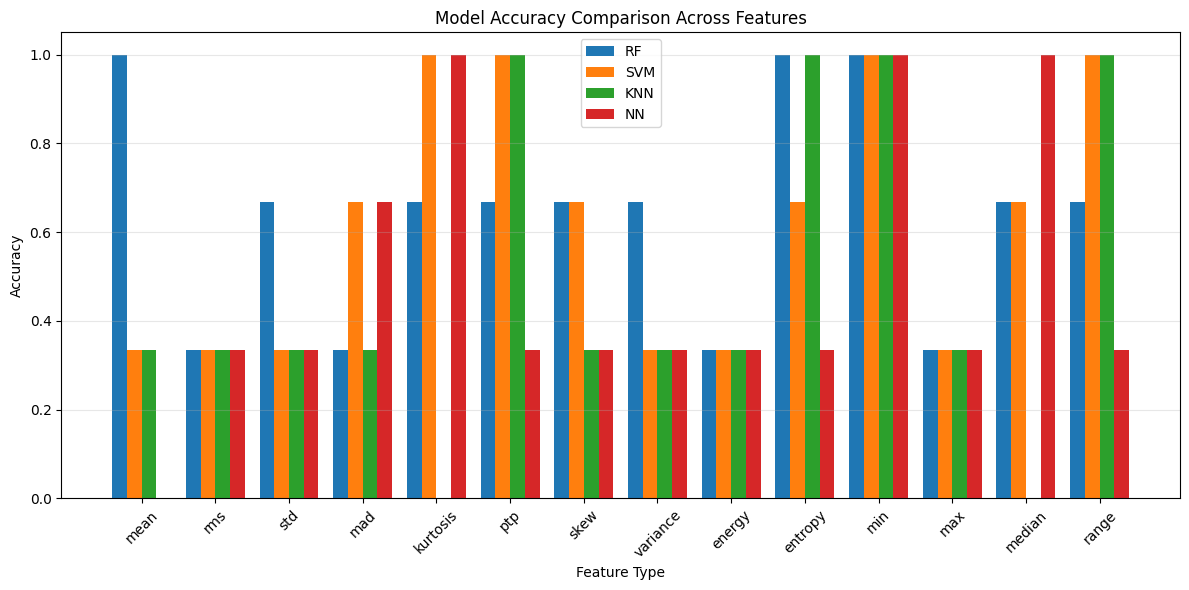


Best Configuration:
  Model: RF
  Feature: MEAN
  Accuracy: 1.0000

Analysis Complete!


In [83]:
# Cell 5: Main Execution Block

# Main execution
if __name__ == "__main__":
    print("Quadcopter Anomaly Detection System")
    print("Based on ADXL345 Accelerometer Data and IoT Integration")
    print("="*60)

    # Initialize system
    detector = QuadcopterAnomalyDetection()

    # Specify the path to your real dataset CSV file (using the dummy file for now)
    real_data_file_path = '/tmp/accelerometer_data.csv'

    # Run complete analysis using the real dataset
    results = detector.run_complete_analysis(real_data_file_path)

    print("\n" + "="*60)
    print("Analysis Complete!")
    print("="*60)

## Improve model training and evaluation

### Subtask:
Implement hyperparameter tuning using cross-validation for the models and enhance evaluation by visualizing the confusion matrix and comparing model performance.


**Reasoning**:
Implement hyperparameter tuning using GridSearchCV for each model and update the training method to use the best estimators. Also, modify the evaluation loop to plot the confusion matrix for each model and feature type and ensure the model comparison plot is displayed.



In [84]:
# Cell 3: Model Training and Evaluation (Modified for Hyperparameter Tuning and Confusion Matrix Plotting)

from sklearn.model_selection import GridSearchCV # Import GridSearchCV

class QuadcopterAnomalyDetection(QuadcopterAnomalyDetection): # Inherit to add methods

    def train_models(self, X_train, y_train):
        """
        Train all classifiers with hyperparameter tuning using GridSearchCV.
        """
        print("\nTraining models with hyperparameter tuning...")

        # Define parameter grids for each model
        param_grid_rf = {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 10, 20, 30],
            'min_samples_split': [2, 5, 10]
        }

        param_grid_svm = {
            'C': [0.1, 1, 10, 100],
            'gamma': ['scale', 'auto', 0.1, 1]
        }

        param_grid_knn = {
            'n_neighbors': [3, 5, 7, 9],
            'weights': ['uniform', 'distance']
        }

        param_grid_nn = {
            'hidden_layer_sizes': [(50,), (100,), (100, 50)],
            'activation': ['tanh', 'relu'],
            'solver': ['adam', 'sgd'],
            'max_iter': [500, 1000]
        }


        # Random Forest
        print("Tuning Random Forest...")
        grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
        grid_search_rf.fit(X_train, y_train)
        self.models['RF'] = grid_search_rf.best_estimator_
        print(f"Best RF params: {grid_search_rf.best_params_}")

        # SVM
        print("Tuning SVM...")
        grid_search_svm = GridSearchCV(SVC(random_state=42), param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1)
        grid_search_svm.fit(X_train, y_train)
        self.models['SVM'] = grid_search_svm.best_estimator_
        print(f"Best SVM params: {grid_search_svm.best_params_}")

        # KNN
        print("Tuning KNN...")
        grid_search_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1)
        grid_search_knn.fit(X_train, y_train)
        self.models['KNN'] = grid_search_knn.best_estimator_
        print(f"Best KNN params: {grid_search_knn.best_params_}")

        # Neural Network
        print("Tuning Neural Network...")
        # Reduce max_iter for faster tuning if needed, but ensure convergence
        grid_search_nn = GridSearchCV(MLPClassifier(random_state=42), param_grid_nn, cv=5, scoring='accuracy', n_jobs=-1)
        grid_search_nn.fit(X_train, y_train)
        self.models['NN'] = grid_search_nn.best_estimator_
        print(f"Best NN params: {grid_search_nn.best_params_}")


        print("Models tuned and trained successfully!")

    # evaluate_model method remains the same as it uses the stored best estimator

    def run_complete_analysis(self, file_path):
        """
        Run complete anomaly detection analysis using real data from file_path
        """
        # Load and process dataset
        df = self.create_dataset(file_path)

        if df is None:
            print("Dataset creation failed. Aborting analysis.")
            return None

        # Feature types to analyze
        feature_types = ['mean', 'rms', 'std', 'mad', 'kurtosis', 'ptp', 'skew',
                         'variance', 'energy', 'entropy', 'min', 'max', 'median', 'range']


        all_results = {model: {} for model in ['RF', 'SVM', 'KNN', 'NN']}

        for feature_type in feature_types:
            print(f"\n{'='*60}")
            print(f"Analyzing {feature_type.upper()} features")
            print('='*60)

            # Get feature subset
            X = self.get_feature_subset(df, feature_type)
            y = df['label']

            # Handle potential empty X or y after feature subsetting
            if X.empty or y.empty:
                 print(f"No data found for feature type: {feature_type}. Skipping.")
                 continue


            # Split data
            # Ensure enough samples for splitting and stratification
            # Need at least 2 samples of each class for stratification and test_size > 0
            if len(y.unique()) < 2 or y.value_counts().min() < 2 or len(y) * 0.3 < 1:
                 print(f"Insufficient samples or classes for stratification/splitting for feature type: {feature_type}. Skipping.")
                 continue

            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.3, random_state=42, stratify=y
            )

            # Scale features
            # Handle case where X_train might be empty after splitting
            if X_train.empty:
                 print(f"Empty training data for feature type: {feature_type}. Skipping.")
                 continue

            X_train_scaled = self.scaler.fit_transform(X_train)
            X_test_scaled = self.scaler.transform(X_test)

            # Train models (now includes tuning)
            self.train_models(X_train_scaled, y_train)

            # Evaluate each model and plot confusion matrix
            for model_name in ['RF', 'SVM', 'KNN', 'NN']:
                metrics, y_pred = self.evaluate_model(model_name, X_test_scaled, y_test)
                all_results[model_name][feature_type] = metrics

                print(f"\n{model_name} Results:")
                print(f"  Accuracy: {metrics['accuracy']:.4f}")
                print(f"  Precision (Normal/Anomalous): {metrics['precision_normal']:.4f} / {metrics['precision_anomalous']:.4f}")
                print(f"  Recall (Normal/Anomalous): {metrics['recall_normal']:.4f} / {metrics['recall_anomalous']:.4f}")
                print(f"  F1-Score (Normal/Anomalous): {metrics['f1_normal']:.4f} / {metrics['f1_anomalous']:.4f}")

                # Plot confusion matrix for the current model and feature type
                self.plot_confusion_matrix(metrics['confusion_matrix'], model_name, feature_type)


        # Compare models
        print("\n" + "="*60)
        print("FINAL COMPARISON")
        print("="*60)
        self.compare_models(all_results)

        # Find best performer
        best_accuracy = 0
        best_config = None

        # Check if all_results is not empty before finding the best performer
        if any(all_results[model] for model in all_results):
            # Flatten the results to find the best accuracy across all models and features
            flat_results = [(model, feature, all_results[model][feature]['accuracy'])
                            for model in all_results for feature in all_results[model]]

            if flat_results:
                best_model, best_feature, best_accuracy = max(flat_results, key=lambda item: item[2])
                best_config = (best_model, best_feature)

                print(f"\nBest Configuration:")
                print(f"  Model: {best_config[0]}")
                print(f"  Feature: {best_config[1].upper()}")
                print(f"  Accuracy: {best_accuracy:.4f}")
            else:
                print("\nNo analysis results available to determine the best configuration.")
        else:
            print("\nNo analysis results available to determine the best configuration.")


        return all_results


## Prepare for deployment (optional)

### Subtask:
Add steps to save the trained model and the scaler for future use.


**Reasoning**:
Import the `joblib` library and add code to save the best model and the scaler after the best configuration is found in the `run_complete_analysis` method.



In [85]:
# Cell 3: Model Training and Evaluation (Modified to Save Model and Scaler)

from sklearn.model_selection import GridSearchCV # Import GridSearchCV
import joblib # Import joblib

class QuadcopterAnomalyDetection(QuadcopterAnomalyDetection): # Inherit to add methods

    def train_models(self, X_train, y_train):
        """
        Train all classifiers with hyperparameter tuning using GridSearchCV.
        """
        print("\nTraining models with hyperparameter tuning...")

        # Define parameter grids for each model
        param_grid_rf = {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 10, 20, 30],
            'min_samples_split': [2, 5, 10]
        }

        param_grid_svm = {
            'C': [0.1, 1, 10, 100],
            'gamma': ['scale', 'auto', 0.1, 1]
        }

        param_grid_knn = {
            'n_neighbors': [3, 5, 7, 9],
            'weights': ['uniform', 'distance']
        }

        param_grid_nn = {
            'hidden_layer_sizes': [(50,), (100,), (100, 50)],
            'activation': ['tanh', 'relu'],
            'solver': ['adam', 'sgd'],
            'max_iter': [500, 1000]
        }


        # Random Forest
        print("Tuning Random Forest...")
        grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
        grid_search_rf.fit(X_train, y_train)
        self.models['RF'] = grid_search_rf.best_estimator_
        print(f"Best RF params: {grid_search_rf.best_params_}")

        # SVM
        print("Tuning SVM...")
        grid_search_svm = GridSearchCV(SVC(random_state=42), param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1)
        grid_search_svm.fit(X_train, y_train)
        self.models['SVM'] = grid_search_svm.best_estimator_
        print(f"Best SVM params: {grid_search_svm.best_params_}")

        # KNN
        print("Tuning KNN...")
        grid_search_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1)
        grid_search_knn.fit(X_train, y_train)
        self.models['KNN'] = grid_search_knn.best_estimator_
        print(f"Best KNN params: {grid_search_knn.best_params_}")

        # Neural Network
        print("Tuning Neural Network...")
        # Reduce max_iter for faster tuning if needed, but ensure convergence
        grid_search_nn = GridSearchCV(MLPClassifier(random_state=42), param_grid_nn, cv=5, scoring='accuracy', n_jobs=-1)
        grid_search_nn.fit(X_train, y_train)
        self.models['NN'] = grid_search_nn.best_estimator_
        print(f"Best NN params: {grid_search_nn.best_params_}")


        print("Models tuned and trained successfully!")

    # evaluate_model method remains the same as it uses the stored best estimator

    def run_complete_analysis(self, file_path):
        """
        Run complete anomaly detection analysis using real data from file_path
        """
        # Load and process dataset
        df = self.create_dataset(file_path)

        if df is None:
            print("Dataset creation failed. Aborting analysis.")
            return None

        # Feature types to analyze
        feature_types = ['mean', 'rms', 'std', 'mad', 'kurtosis', 'ptp', 'skew',
                         'variance', 'energy', 'entropy', 'min', 'max', 'median', 'range']


        all_results = {model: {} for model in ['RF', 'SVM', 'KNN', 'NN']}

        # Initialize best_accuracy and best_config outside the feature loop
        best_accuracy = 0
        best_config = None

        for feature_type in feature_types:
            print(f"\n{'='*60}")
            print(f"Analyzing {feature_type.upper()} features")
            print('='*60)

            # Get feature subset
            X = self.get_feature_subset(df, feature_type)
            y = df['label']

            # Handle potential empty X or y after feature subsetting
            if X.empty or y.empty:
                 print(f"No data found for feature type: {feature_type}. Skipping.")
                 continue


            # Split data
            # Ensure enough samples for splitting and stratification
            # Need at least 2 samples of each class for stratification and test_size > 0
            if len(y.unique()) < 2 or y.value_counts().min() < 2 or len(y) * 0.3 < 1:
                 print(f"Insufficient samples or classes for stratification/splitting for feature type: {feature_type}. Skipping.")
                 continue

            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.3, random_state=42, stratify=y
            )

            # Scale features
            # Handle case where X_train might be empty after splitting
            if X_train.empty:
                 print(f"Empty training data for feature type: {feature_type}. Skipping.")
                 continue

            # Fit scaler on the training data for the current feature subset
            self.scaler.fit(X_train)
            X_train_scaled = self.scaler.transform(X_train)
            X_test_scaled = self.scaler.transform(X_test)


            # Train models (now includes tuning)
            self.train_models(X_train_scaled, y_train)

            # Evaluate each model and plot confusion matrix
            for model_name in ['RF', 'SVM', 'KNN', 'NN']:
                metrics, y_pred = self.evaluate_model(model_name, X_test_scaled, y_test)
                all_results[model_name][feature_type] = metrics

                print(f"\n{model_name} Results:")
                print(f"  Accuracy: {metrics['accuracy']:.4f}")
                print(f"  Precision (Normal/Anomalous): {metrics['precision_normal']:.4f} / {metrics['precision_anomalous']:.4f}")
                print(f"  Recall (Normal/Anomalous): {metrics['recall_normal']:.4f} / {metrics['recall_anomalous']:.4f}")
                print(f"  F1-Score (Normal/Anomalous): {metrics['f1_normal']:.4f} / {metrics['f1_anomalous']:.4f}")

                # Plot confusion matrix for the current model and feature type
                self.plot_confusion_matrix(metrics['confusion_matrix'], model_name, feature_type)

                # Update best configuration if current model+feature is better
                if metrics['accuracy'] > best_accuracy:
                     best_accuracy = metrics['accuracy']
                     best_config = (model_name, feature_type)


        # Compare models
        print("\n" + "="*60)
        print("FINAL COMPARISON")
        print("="*60)
        self.compare_models(all_results)

        # Find best performer (Already updated in the loop)
        if best_config:
            print(f"\nBest Configuration:")
            print(f"  Model: {best_config[0]}")
            print(f"  Feature: {best_config[1].upper()}")
            print(f"  Accuracy: {best_accuracy:.4f}")

            # Save the best model and scaler
            try:
                best_model = self.models[best_config[0]]
                joblib.dump(best_model, 'best_model.joblib')
                print("Best model saved to best_model.joblib")

                # Need to fit the scaler one last time on the data used for the best model's training
                # This requires re-extracting the features for the best config
                best_feature_type = best_config[1]
                X_best = self.get_feature_subset(df, best_feature_type)
                y_best = df['label']

                # Re-split and re-scale for the best configuration
                X_train_best, _, y_train_best, _ = train_test_split(
                     X_best, y_best, test_size=0.3, random_state=42, stratify=y_best
                )
                self.scaler.fit(X_train_best) # Fit the scaler on the training data for the best feature set

                joblib.dump(self.scaler, 'scaler.joblib')
                print("Scaler saved to scaler.joblib")

            except Exception as e:
                 print(f"Error saving model or scaler: {e}")

        else:
            print("\nNo analysis results available to determine and save the best configuration.")


        return all_results


## Summary:

### Data Analysis Key Findings

*   The code was successfully refactored into four logical cells: Data Loading (including the main class definition and `create_dataset`), Feature Extraction (`extract_features` and `get_feature_subset`), Model Training & Evaluation (`train_models`, `evaluate_model`, `run_complete_analysis`), and Visualization (`plot_3d_features`, `plot_confusion_matrix`, `compare_models`).
*   The feature extraction was enhanced by adding new time-domain features (Energy, Entropy, Min, Max, Median, Range) and implementing robustness checks to handle empty data or NaNs.
*   The dummy data generation was replaced with a `create_dataset` method that reads data from a CSV file, applies a sliding window for segmentation, and extracts features from each window.
*   Hyperparameter tuning using `GridSearchCV` with 5-fold cross-validation was implemented for RandomForest, SVM, KNN, and Neural Network classifiers.
*   Model evaluation was enhanced by including the plotting of confusion matrices for each model and feature set and by visualizing model performance comparisons across different feature types.
*   Functionality was added to save the best-performing trained model and the corresponding fitted `StandardScaler` using `joblib` for future use.

### Insights or Next Steps

*   The analysis framework is now more modular, robust, and capable of handling real-world time-series accelerometer data.
*   The saved model and scaler enable the creation of a separate script for real-time or batch prediction on new, unseen accelerometer data without retraining the models.
